# Service Alert Delay Correlation

Compares observed delays during active service alerts with observations without active alerts.

In [1]:
from pathlib import Path
import importlib.util
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "analysis"))

spec = importlib.util.spec_from_file_location(
    "service_alert_delay_correlation",
    PROJECT_ROOT / "analysis" / "service-alert-delay-correlation.py",
)
service_alerts = importlib.util.module_from_spec(spec)
spec.loader.exec_module(service_alerts)

DB = PROJECT_ROOT / "data" / "foli.db"
GTFS_DIR = None
LIMIT = 20
MIN_OBSERVATIONS = 100
ALERT_KIND = "route"  # "route", "stop", or "any"
LINE_REF = None
TIMEZONE = "Europe/Helsinki"
QUALITY_MODE = "conservative"
BUCKET = "trip-stop"

Alert rows are grouped by cause, effect, priority, and route/stop scope. Controls are matched from non-alert buckets with the same line, direction, local hour, and weekday/weekend context.

In [2]:
class Args:
    db = DB
    gtfs_dir = GTFS_DIR
    limit = LIMIT
    min_observations = MIN_OBSERVATIONS
    alert_kind = ALERT_KIND
    line_ref = LINE_REF
    timezone = TIMEZONE
    quality_mode = QUALITY_MODE
    exclude_stop_call_disagreement = False
    bucket = BUCKET

grouped, line = service_alerts.build_correlation(Args)
grouped

,cause,effect,priority,alert_scope,bucket_count_control,bucket_count_alert,raw_poll_count_control,raw_poll_count_alert,median_delay_min_control,median_delay_min_alert,median_delay_lift_min,p90_delay_min_control,p90_delay_min_alert,p90_delay_lift_min,pct_over_5_min_late_control,pct_over_5_min_late_alert,over_5_min_late_pct_point_lift,pct_over_3_min_early_control,pct_over_3_min_early_alert
1,TECHNICAL_PROBLEM,Unknown,1200,route,22878,58602,58918,149119,-0.17,-0.17,0.00,2.23,2.17,-0.07,2.17,1.87,-0.30,9.17,11.13
0,OTHER_CAUSE,Unknown,1200,route,10144,8135,25365,20250,-0.02,-0.15,-0.13,2.37,2.02,-0.35,2.39,1.34,-1.05,13.53,14.11


In [3]:
line

,cause,effect,priority,alert_scope,line_ref,line_name,bucket_count_control,bucket_count_alert,raw_poll_count_control,raw_poll_count_alert,...,median_delay_min_alert,median_delay_lift_min,p90_delay_min_control,p90_delay_min_alert,p90_delay_lift_min,pct_over_5_min_late_control,pct_over_5_min_late_alert,over_5_min_late_pct_point_lift,pct_over_3_min_early_control,pct_over_3_min_early_alert
5,TECHNICAL_PROBLEM,Unknown,1200,route,21,21,496,355,854,613,...,2.97,2.15,3.93,9.13,5.19,7.86,29.58,21.71,4.23,0.00
4,TECHNICAL_PROBLEM,Unknown,1200,route,20,20,959,2173,3070,6680,...,-0.27,-0.13,0.88,1.11,0.22,0.00,0.14,0.14,5.32,8.79
0,OTHER_CAUSE,Unknown,1200,route,3,3,6903,5393,17287,13424,...,-0.08,0.00,2.32,2.27,-0.05,2.40,1.63,-0.77,13.75,13.87
6,TECHNICAL_PROBLEM,Unknown,1200,route,3,3,7982,26244,20861,66495,...,-0.12,-0.05,2.36,2.22,-0.14,1.85,1.87,0.01,12.82,13.46
2,TECHNICAL_PROBLEM,Unknown,1200,route,10,10,4871,7167,12185,18206,...,-0.60,-0.12,1.02,0.85,-0.17,0.74,0.10,-0.64,6.98,8.64
9,TECHNICAL_PROBLEM,Unknown,1200,route,601,601,875,2332,1960,5439,...,-0.68,-0.13,0.64,0.42,-0.23,0.00,0.00,0.00,2.74,4.55
8,TECHNICAL_PROBLEM,Unknown,1200,route,600,600,901,2363,2047,5289,...,-0.70,-0.15,0.85,0.57,-0.28,0.44,0.63,0.19,8.66,10.41
3,TECHNICAL_PROBLEM,Unknown,1200,route,10A,10A,1805,1172,5255,3364,...,-0.40,-0.07,1.32,0.99,-0.32,1.99,0.00,-1.99,2.94,3.67
7,TECHNICAL_PROBLEM,Unknown,1200,route,6,6,4989,16796,12686,43033,...,0.17,-0.17,3.53,2.92,-0.62,4.69,2.84,-1.85,10.16,10.63
1,OTHER_CAUSE,Unknown,1200,route,6,6,3241,2742,8078,6826,...,-0.23,-0.28,2.48,1.57,-0.92,2.34,0.77,-1.58,13.05,14.59


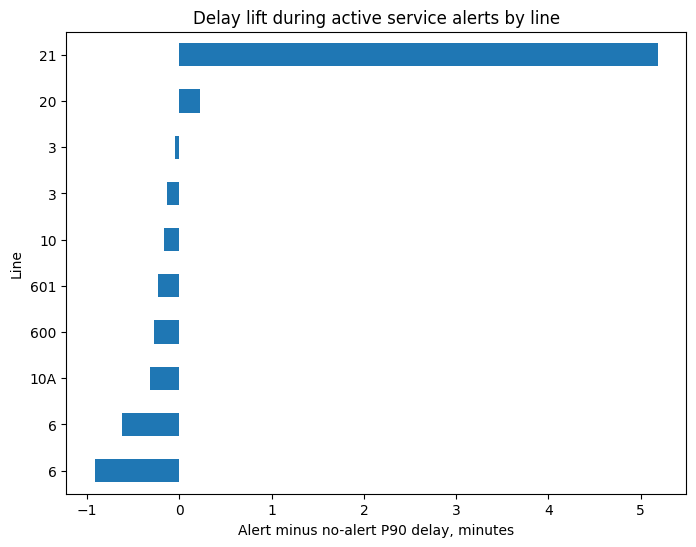

In [4]:
if not line.empty:
    ax = line.sort_values("p90_delay_lift_min").plot.barh(
        x="line_ref",
        y="p90_delay_lift_min",
        legend=False,
        figsize=(8, 6),
        title="Delay lift during active service alerts by line",
    )
    ax.set_xlabel("Alert minus no-alert P90 delay, minutes")
    ax.set_ylabel("Line")